<div style="background-color: darkred; padding: 10px; color: white;">

# Soma Shape Estimation

</div>

### Imports

In [ ]:

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_exaspim_soma_detection import soma_proposal_generation as spg
from aind_exaspim_soma_detection.utils import img_util, util

%matplotlib inline

### Subroutines

In [2]:
def get_soma_center(patch, n_cells=1):
    # Proposal generation
    proposals_1 = spg.detect_blobs(patch, 100, 16, 0)
    proposals_2 = spg.detect_blobs(patch, 100, 10, 0)
    proposals_3 = spg.detect_blobs(patch, 100, 5, 0)
    proposals = proposals_1 + proposals_2 + proposals_3

    # Filter proposals
    proposals = spg.spatial_filtering(proposals, 10)
    # print(f"{len(proposals)} proposals found")

    # pick brightest
    # top = spg.brightness_filtering(patch, proposals, n_cells)[0]

    # pick closest to guess
    top = proposals[np.argmin([np.linalg.norm(x - np.array(patch.shape)/2) for x in proposals ])]
    return top


def get_nbhd(patch, voxel, r=30):
    x0, y0, z0 = tuple(map(int, voxel))
    x_min, x_max = max(0, x0 - r), min(patch.shape[0], x0 + r + 1)
    y_min, y_max = max(0, y0 - r), min(patch.shape[1], y0 + r + 1)
    z_min, z_max = max(0, z0 - r), min(patch.shape[2], z0 + r + 1)
    return patch[x_min:x_max, y_min:y_max, z_min:z_max]


def fit_rotated_gaussian(nbhd):
    c = [s // 2 for s in nbhd.shape]
    voxels = np.stack(np.meshgrid(
        np.arange(nbhd.shape[0]),
        np.arange(nbhd.shape[1]),
        np.arange(nbhd.shape[2]),
        indexing='ij'
    ), -1).reshape(-1, 3)

    p0 = [c[0], c[1], c[2], 1e-2, 0, 0, 1e-2, 0, 1e-2, np.max(nbhd), np.min(nbhd)]

    try:
        params, _ = curve_fit(gaussian_3d_rotated, voxels, nbhd.ravel(), p0=p0)
    except RuntimeError:
        params = np.zeros((11,))
    return params, voxels


def gaussian_3d_rotated(coords, x0, y0, z0, a11, a12, a13, a22, a23, a33, A, B):
    # Refactor coordinates
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    dx = x - x0
    dy = y - y0
    dz = z - z0

    # Construct quadratic form
    quad = (
        a11*dx**2 + 2*a12*dx*dy + 2*a13*dx*dz +
        a22*dy**2 + 2*a23*dy*dz + a33*dz**2
    )
    return A * np.exp(-0.5 * quad) + B


def gaussian_fit_score(image_patch, fitted_patch, params, voxels):
    # Unpack parameters
    x0, y0, z0, a11, a12, a13, a22, a23, a33, A, B = params

    # Compute dx, dy, dz
    dx = voxels[:, 0] - x0
    dy = voxels[:, 1] - y0
    dz = voxels[:, 2] - z0

    # Compute quadratic form Q(x)
    quad = (
        a11 * dx**2 + 2 * a12 * dx * dy + 2 * a13 * dx * dz +
        a22 * dy**2 + 2 * a23 * dy * dz + a33 * dz**2
    )

    # Mask: only voxels within 2 std devs
    mask = quad <= 4

    # Flatten patches to align with voxels
    y_true = image_patch.ravel()[mask]
    y_pred = fitted_patch.ravel()[mask]

    # Compute R²
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0


def estimate_radii(params, anisotropy=(2.992, 2.992, 4.0)):
    # Compute precision matrix
    _, _, _, a11, a12, a13, a22, a23, a33, _, _ = params
    P_voxel = np.array([
        [a11, a12, a13],
        [a12, a22, a23],
        [a13, a23, a33]
    ])

    # Convert precision matrix from voxel to physical space
    S = np.diag(anisotropy)
    S_inv = np.linalg.inv(S)

    # Adjusted precision matrix in physical units
    # need to flip order
    P_physical = S_inv.T @ P_voxel @ S_inv
    try:
        cov_physical = np.linalg.inv(P_physical)
        # eigvals = np.linalg.eigvalsh(cov_physical)
        eigvals, eigvecs = np.linalg.eigh(cov_physical)
        radii = 2 * np.sqrt(np.abs(eigvals))
        return radii, eigvecs[::-1, :]
    except np.linalg.LinAlgError:
        return None


def run_shape_estimation(img, xyz, multiscale=2, patch_shape=(50, 50, 50)):
    # Get soma center
    voxel = img_util.to_voxels(xyz, multiscale)
    patch = img_util.get_patch(img, voxel, patch_shape)
    patch_filt = gaussian_filter(patch, sigma=1)
    soma_center = get_soma_center(patch_filt)
    voxel_offset = np.array(soma_center) - np.array(patch_shape)/2 
    soma_offset = np.array(img_util.to_physical(voxel_offset, multiscale))
    voxel_offset = np.rint(voxel_offset).astype(int)
    
    # Fit Gaussian
    # blob = get_nbhd(patch, soma_center, r=20)
    blob = img_util.get_patch(img, voxel+voxel_offset, patch_shape)
    params, voxels = fit_rotated_gaussian(blob)
    fitted_blob = gaussian_3d_rotated(voxels, *params).reshape(blob.shape)

    # Report results
    radii, eigvecs = estimate_radii(params)
    volume = np.prod(radii) * (4 / 3) * np.pi
    result = {
        "soma": xyz,
        "soma_offset": soma_offset,
        "radii": radii,
        "volume": volume,
        "rsquared": gaussian_fit_score(blob, fitted_blob, params, voxels),
        "primary_axis": eigvecs[:, 2],
    }
    return result, blob, fitted_blob

<div style="background-color: darkblue; padding: 10px; color: white;">

## Section 1: Load Data
    
</div>

### Initializations

In [3]:
from glob import glob
records = {}
for swc in glob("/data/lc_image_space_reconstructions/*/*.swc")[:] + glob("/data/lc_image_space_new/*/*.swc"):
    id = swc.split("/")[-1][:11]
    soma = pd.read_csv(swc, sep=" ", nrows=1, names=["0","1","x","y","z","2","3"], usecols=["x","y","z"])
    record = soma.iloc[0].to_dict()
    # overwrite old with new
    record["id"] = id
    record["path"] = swc
    records[id] = record

somas_df = pd.DataFrame.from_records(list(records.values()), index="id")
somas_df["brain"] = somas_df.index.to_series().apply(lambda x: x.split("-")[-1])
somas_df.head()

,x,y,z,path,brain
id,,,,,
N010-685222,14720.694400,11631.797800,16186.722727,/data/lc_image_space_reconstructions/685222-im...,685222
N038-685222,14449.910692,9914.868864,10556.101253,/data/lc_image_space_reconstructions/685222-im...,685222
N008-685222,15115.202169,11593.030881,16119.537637,/data/lc_image_space_reconstructions/685222-im...,685222
N009-685222,15033.155651,11621.781787,16276.059435,/data/lc_image_space_reconstructions/685222-im...,685222
N026-685222,15364.571216,11265.093714,10624.452406,/data/lc_image_space_reconstructions/685222-im...,685222


### Images

In [4]:
import zarr
from s3fs import S3FileSystem

multiscale=2
img_prefixes = util.read_json("/root/capsule/data/exaspim_image_prefixes.json")

fs = S3FileSystem(anon=True)
imgs = dict()
for brain_id in somas_df["brain"].unique():
        # imgs[brain_id] = img_util.open_img(img_prefixes[brain_id] + str(multiscale))
    path = fs.glob(f"s3://{img_prefixes[brain_id] + str(multiscale)}")[0]
    imgs[brain_id] = zarr.open(path, mode='r', storage_options={'anon': True})


### Process Dataset

In [5]:

results = list()
for id in tqdm(somas_df.index[:]):
    # Extract info
    brain_id = id.split("-")[-1]
    xyz = somas_df.loc[id, ["x", "y", "z"]].values.astype("float")

    # Estimate soma shape
    # if brain_id in brains:
    res, _, _ = run_shape_estimation(imgs[brain_id], xyz)
    res["id"] = id
    results.append(res)



100%|██████████| 132/132 [02:40<00:00,  1.22s/it]


In [6]:
double_cells = [
    "N022-648434",
    "N018-685221",
    "N023-685221",
    "N040-685221",
    "N064-685221",
    "N065-685221",
    "N012-685222",
    "N013-685222",
]

df = pd.DataFrame(results).set_index("id").join(somas_df[["path", "brain"]])
df.loc[double_cells, ["radii", "volume", "rsquared", "primary_axis"]] = np.nan
df.to_csv("/scratch/LC_soma_shapes.csv")

### local images

In [7]:
# from glob import glob
# import zarr
# imgs = {}
# for brain_id in tqdm(brains):
    # imgs[brain_id] = img_util.open_img(glob(f"/data/exaSPIM_{brain_id}_*/fused.zarr/{multiscale}")[0])
    # imgs[brain_id] = zarr.open(glob(f"/data/exaSPIM_{brain_id}_*/fused.zarr/{multiscale}")[0], mode='r')

### Visualize Example

<div style="background-color: darkblue; padding: 10px; color: white;">

## Section 2: Estimate Shape with Fitted Gaussian

</div>

### Single Cell Example

{'soma': array([30324.927904, 14160.058789, 10062.895872]), 'soma_offset': array([  2.49333333, -14.96      , -13.66666667]), 'radii': array([25.5851016 , 31.91264036, 50.7350011 ]), 'volume': 173518.6528295161, 'rsquared': 0.8357776365041777, 'primary_axis': array([ 0.9045538 ,  0.11646591, -0.41014401])}

Soma Patch


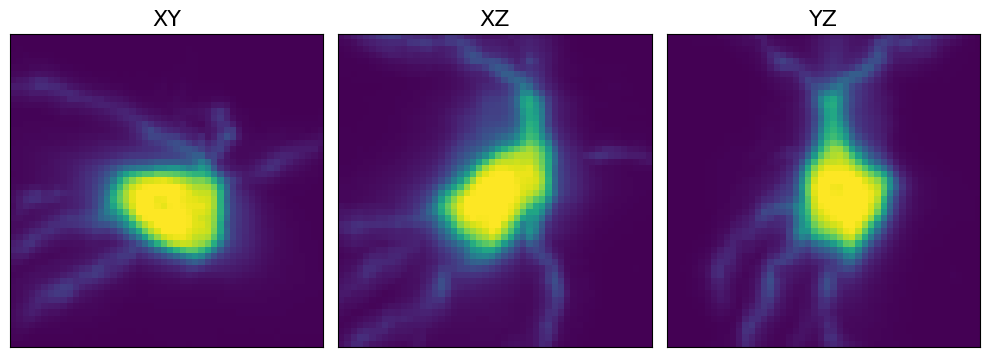


Fitted Gaussian


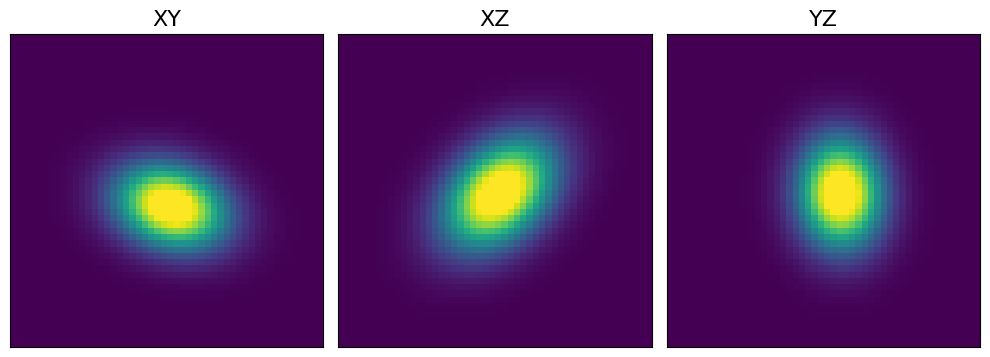

In [8]:
# Sample soma
# idx = util.sample_once(idxs)
id = somas_df.index[3]
id = "N016-685221"
id = "N057-685221"
id = "N026-648434"

# Extract cell info
brain_id = id.split("-")[-1]
soma_xyz = somas_df.loc[id, ["x", "y", "z"]].values.astype("float")

result, blob, fitted_blob = run_shape_estimation(imgs[brain_id], soma_xyz)

print(result)

# Visualize results
print("\nSoma Patch")
img_util.plot_mips(blob)

print("\nFitted Gaussian")
img_util.plot_mips(fitted_blob)

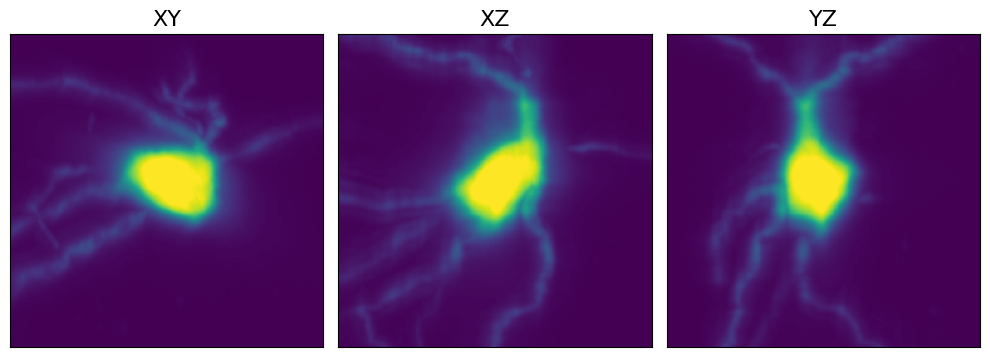

In [9]:
# bigger patch

n = 250
level = 0
soma_voxel = img_util.to_voxels(soma_xyz, level)
path = fs.glob(f"s3://{img_prefixes[brain_id]}{level}")[0]

img = zarr.open(path, mode='r', storage_options={'anon': True})
lower = img_util.to_physical(soma_voxel-n/2, level)
upper = img_util.to_physical(soma_voxel+n/2, level)

patch = img_util.get_patch(img, soma_voxel, (n,n,n))
img_util.plot_mips(patch)

N026-648434


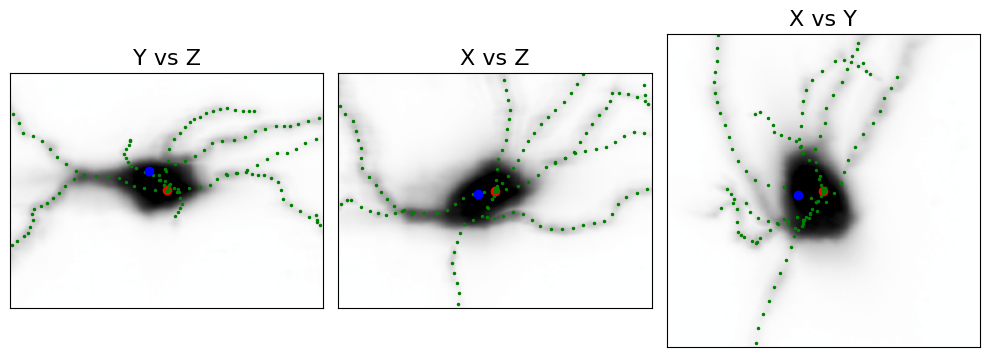

In [10]:
# need to import to access cmaps by name
import colorcet as cc

print(id)
vmax = np.percentile(patch, 99.9)
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

soma = np.array(result["soma"])
soma_offset = soma + np.array(result["soma_offset"])
axis_offset = np.array(result["primary_axis"]) * result["radii"][2]/2
primary = np.stack([soma_offset-axis_offset, soma_offset+axis_offset], -1)

swc = df.loc[id, "path"]
nodes = pd.read_csv(swc, sep=" ", names=["0","1","x","y","z","2","3"], usecols=["x","y","z"])
nodes = nodes.query(
    f"x >= {lower[0]} & x <= {upper[0]} & "
    f"y >= {lower[1]} & y <= {upper[1]} & "
    f"z >= {lower[2]} & z <= {upper[2]}"
).to_numpy().T

for i in range(3):
    axes = list(range(3))
    axes.pop(i)
    axes = axes[::-1]

    # patch axes are reversed
    # remaining mip axes are reversed by imshow to match physical
    mip = np.max(patch, axis=2-i).T
    axs[i].imshow(mip, vmax=vmax, extent=[lower[axes[0]], upper[axes[0]], upper[axes[1]], lower[axes[1]]], cmap="cet_gray_r")
    axs[i].plot(*soma[axes], "ro")
    axs[i].plot(*nodes[axes], "g.", alpha=1, markersize=3)
    axs[i].plot(*soma_offset[axes], "bo")
    # axs[i].plot(*primary[axes], "b-")
    axs[i].set_title(" vs ".join("XYZ"[i] for i in axes[::-1]), fontsize=16)
    axs[i].set_aspect("equal")

    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.tight_layout()
plt.show()

# plots

In [9]:
import bipolarity
from importlib import reload
reload(bipolarity)


<module 'bipolarity' from '/code/bipolarity.py'>

In [10]:

from neuron_morphology.swc_io import morphology_from_swc

names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
names_offset = [x+"_offset" for x in names]
df[names] = None
df[names_offset] = None
df["num_stems"] = None

for id in tqdm(df.index):
    swc = df.loc[id, "path"]
    morph = morphology_from_swc(swc)
    r2 = 50
    stems = bipolarity.intersection_points(morph, cutoff=r2)
    duplicates = []
    for i, stem in enumerate(stems[:len(stems)-1]):
        for j in range(i+1, len(stems)):
            if np.allclose(stem, stems[j], atol=2):
                duplicates.append(j)
    if len(duplicates) > 0:
        print(f"Removing {len(duplicates)} duplicate stems for {id}")
        stems = [s for i, s in enumerate(stems) if i not in duplicates]
        print(f"{len(stems)} stems remain after removing duplicates")
    df.loc[id, "num_stems"] = len(stems)

    soma = np.array(df.loc[id, "soma"])
    primary_axis = np.array(df.loc[id, "primary_axis"])
    df.loc[id, names] = bipolarity.get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)

/opt/conda/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.3) or chardet (6.0.0.post1)/charset_normalizer (3.2.0) doesn't match a supported version!
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
 11%|█▏        | 15/132 [00:16<02:48,  1.44s/it]

Removing 1 duplicate stems for N005-685222
4 stems remain after removing duplicates


 14%|█▍        | 19/132 [00:23<03:11,  1.70s/it]

Removing 1 duplicate stems for N018-685222
4 stems remain after removing duplicates


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3156: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asarray(a).ndim
 26%|██▌       | 34/132 [00:36<01:17,  1.26it/s]/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3156: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asarray(a).ndim
 35%|███▍      | 46/132 [00:42<00:41,  2.06it/s]/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3156: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of l

Removing 1 duplicate stems for N014-685221
3 stems remain after removing duplicates


 91%|█████████ | 120/132 [01:51<00:14,  1.25s/it]

Removing 1 duplicate stems for N013-721332
5 stems remain after removing duplicates


100%|██████████| 132/132 [02:02<00:00,  1.08it/s]


In [12]:
from importlib import reload
reload(bipolarity)

<module 'bipolarity' from '/code/bipolarity.py'>

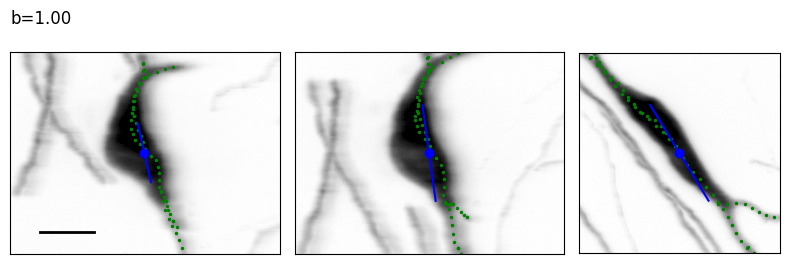

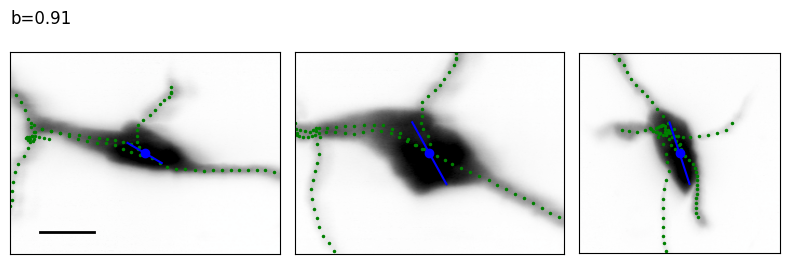

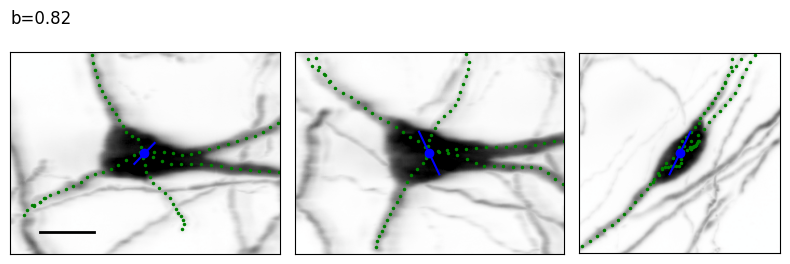

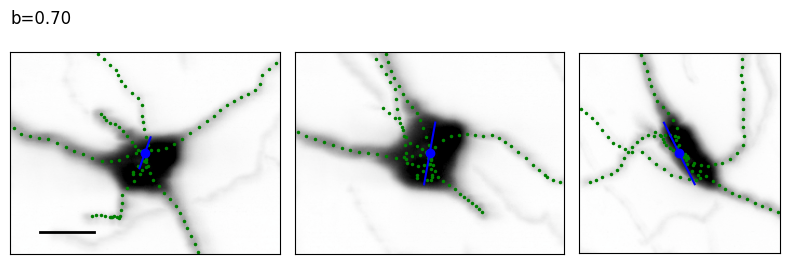

In [19]:
ids = df.sort_values("abs_bipolarity", ascending=False).index.values
inds = [1, 40, 82, 129]
# inds=[1]
for i in inds:
    # print(i)
    bipolarity.plot_soma_all(df, ids[i])
    # plt.suptitle(f"{ids[i]}, b={df.loc[ids[i], 'abs_bipolarity']:.2f}")
    plt.suptitle(f"b={df.loc[ids[i], 'abs_bipolarity']:.2f}", ha="left", x=0.02)
    plt.savefig(f"/scratch/bipolarity_image_{i}.svg")
    plt.show()

### figure composition

In [15]:
import svgutils.compose as svg

In [20]:
i=-1
letters = "abcdefghijkl"
def panel(path, scale=1): 
    global i
    i+=1
    # return svg.Panel(svg.SVG(path).scale(scale), svg.Text(letters[i], 10, 10, size=14, weight='bold'))
    return svg.Panel(svg.SVG(path).scale(scale))

fig = svg.Figure(*100*np.array([6, 8]),
    *[panel(f"/scratch/bipolarity_image_{i}.svg", scale=1) for i in inds]
).tile(1,4)
fig
fig.save("/scratch/supp_bipolarity_gallery.svg")

### other metrics

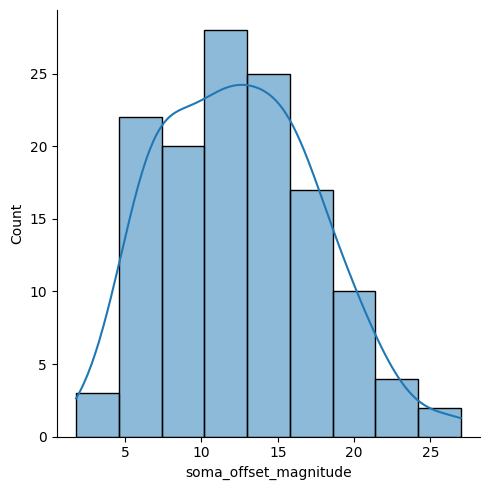

In [ ]:
import seaborn as sns
df["soma_offset_magnitude"] = df["soma_offset"].apply(np.linalg.norm)
sns.displot(df, x="soma_offset_magnitude", kde=True)

(0.0, 300000.0)

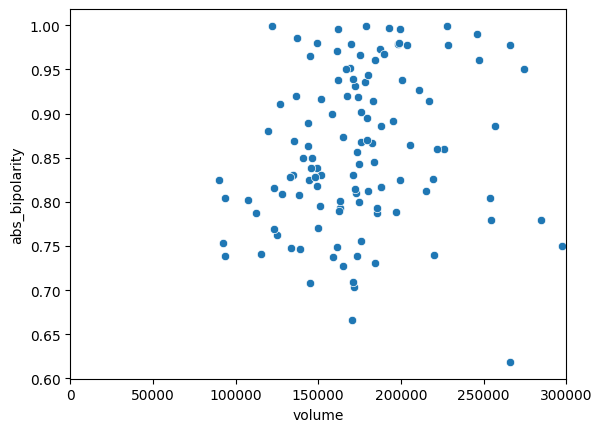

In [30]:
import seaborn as sns
sns.scatterplot(df, x="volume", y="abs_bipolarity")
plt.xlim(0, 3e5)

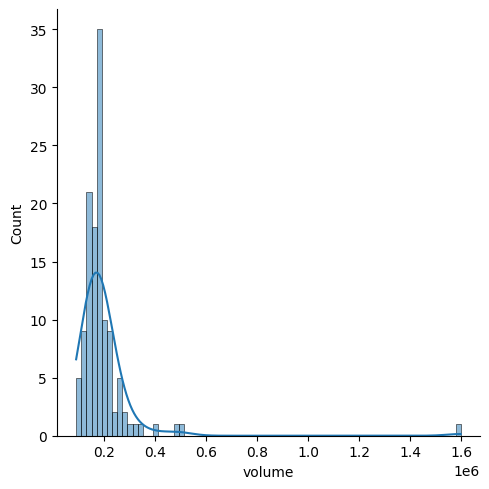

In [ ]:
import seaborn as sns
sns.displot(df, x="volume", kde=True)

N022-648434
{'soma': array([32038.646246, 11480.272711, 11683.353888]), 'soma_offset': array([-0.272     ,  4.352     ,  2.54545455]), 'radii': array([31.2012802 , 34.4912852 , 70.47391004]), 'volume': 317686.5057970025, 'rsquared': 0.7549081043475101, 'primary_axis': array([-0.84942447,  0.45062533, -0.27461768])}

Soma Patch


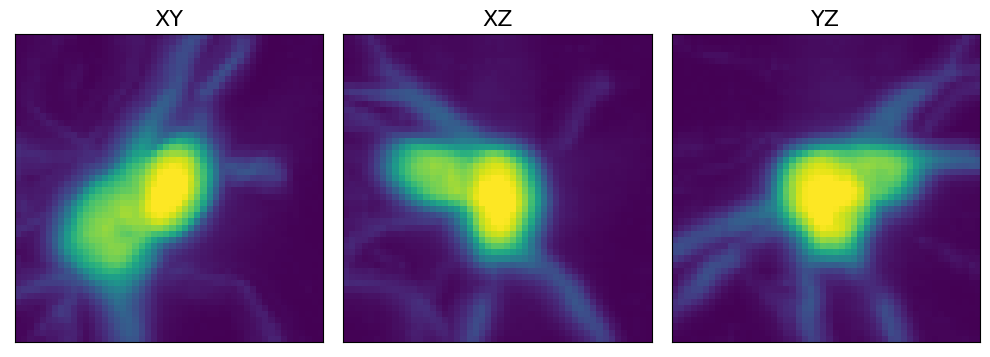


Fitted Gaussian


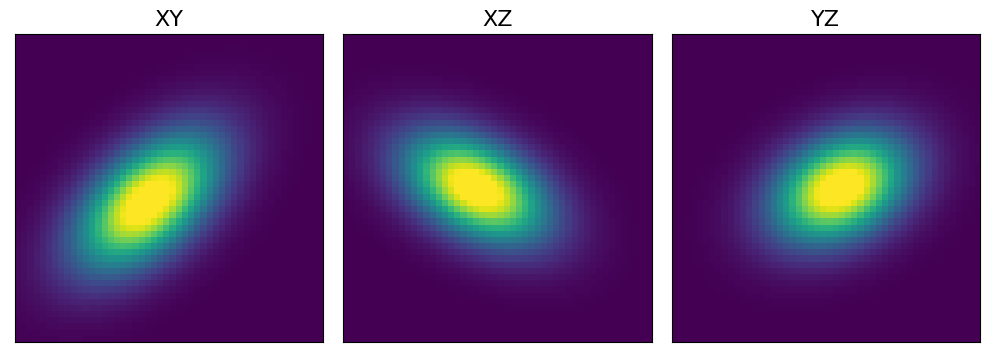

N018-685221
{'soma': array([31801.666644,  9604.676252, 16621.224636]), 'soma_offset': array([-4.98666667, -0.49866667, -1.33333333]), 'radii': array([23.97178749, 68.34676303, 77.15653989]), 'volume': 529516.7741600035, 'rsquared': 0.385765784865414, 'primary_axis': array([ 0.11039373,  0.47244029, -0.87442175])}

Soma Patch


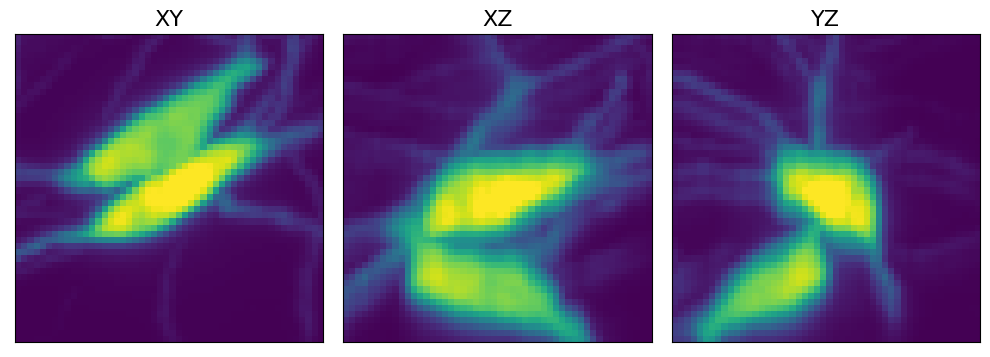


Fitted Gaussian


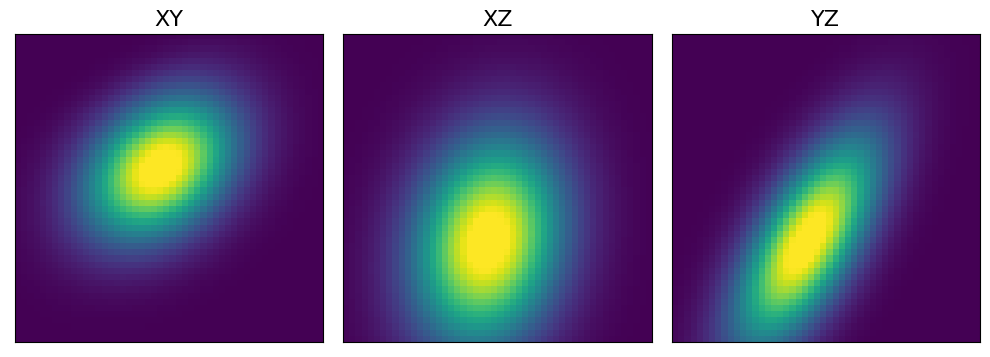

N023-685221
{'soma': array([31786.569226,  9582.639755, 16676.893178]), 'soma_offset': array([-8.228,  1.496, 14.   ]), 'radii': array([23.2361735 , 68.07066225, 80.53309018]), 'volume': 533565.2777877764, 'rsquared': 0.3743099001760307, 'primary_axis': array([-0.18352032, -0.44017734,  0.87895632])}

Soma Patch


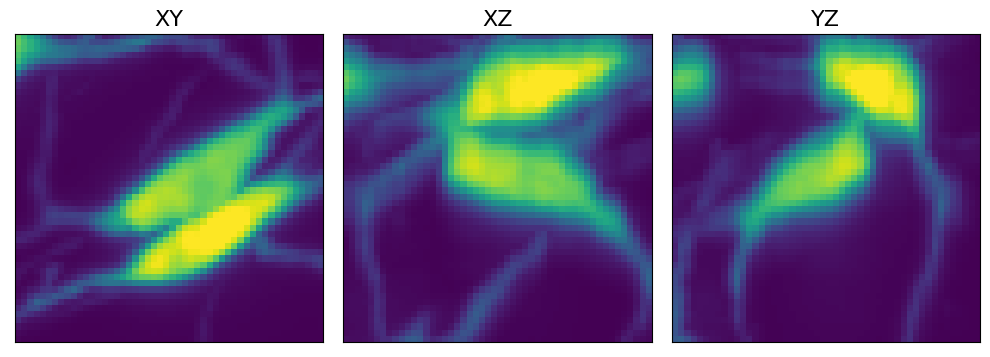


Fitted Gaussian


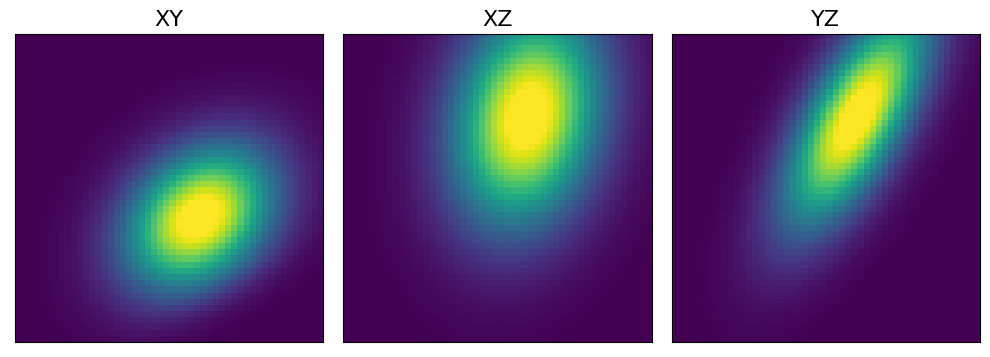

N040-685221
{'soma': array([30746.331514,  9275.356985, 11851.612298]), 'soma_offset': array([10.472,  4.488, 10.   ]), 'radii': array([ 26.23045891,  36.11945471, 131.61049598]), 'volume': 522307.4363279042, 'rsquared': 0.3479355722681916, 'primary_axis': array([-0.83942975,  0.34449323, -0.42033571])}

Soma Patch


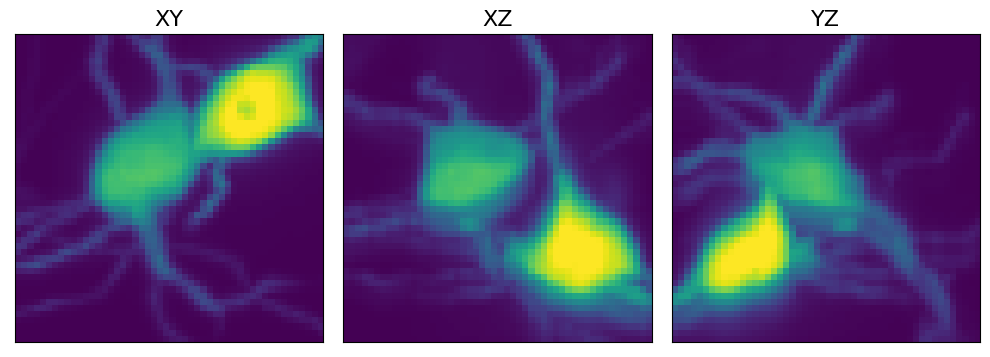


Fitted Gaussian


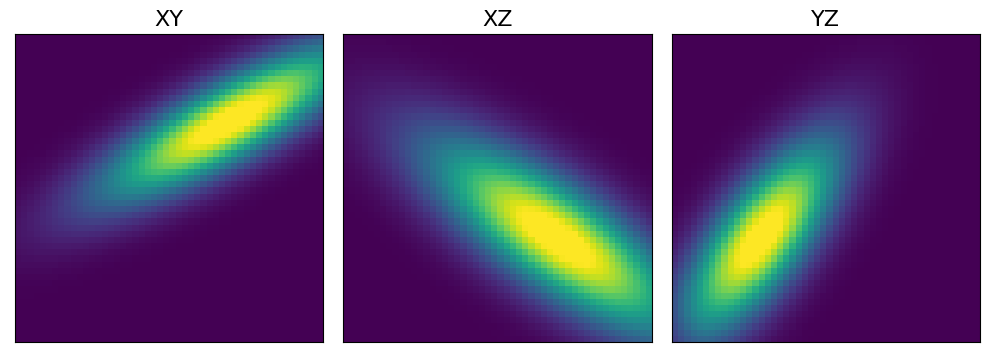

N064-685221
{'soma': array([31810.304006,  9399.453829, 11523.400612]), 'soma_offset': array([ 10.472     , -18.94933333,   2.        ]), 'radii': array([21.89260762, 40.13096515, 83.50896433]), 'volume': 307325.647182171, 'rsquared': 0.4230761198894122, 'primary_axis': array([ 0.80477675, -0.58730139, -0.08608985])}

Soma Patch


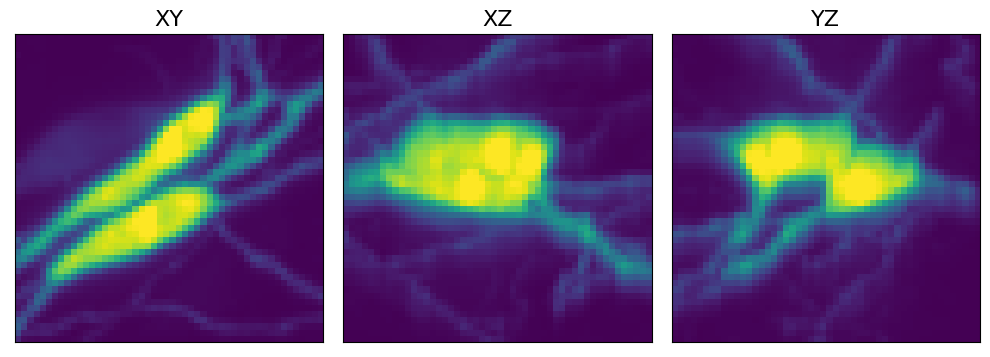


Fitted Gaussian


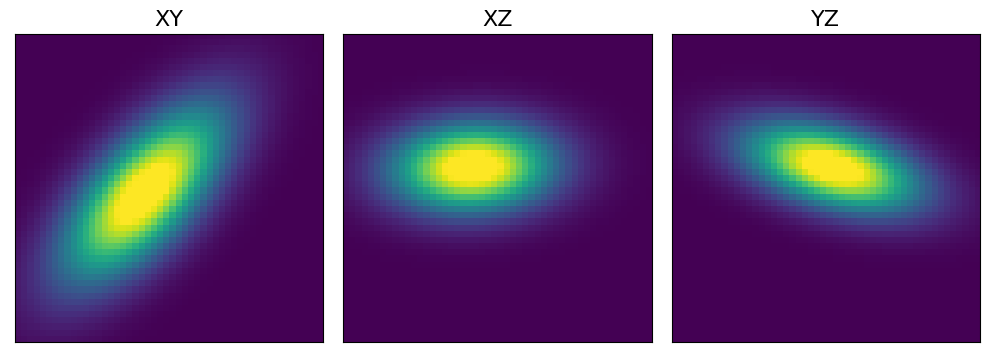

N065-685221
{'soma': array([31813.3949  ,  9368.398102, 11505.233573]), 'soma_offset': array([ 0.42742857, -0.85485714, -6.28571429]), 'radii': array([21.8752766 , 40.17944808, 84.26156616]), 'volume': 310224.1878517571, 'rsquared': 0.4280082246535186, 'primary_axis': array([ 0.8022951 , -0.59037059, -0.08823339])}

Soma Patch


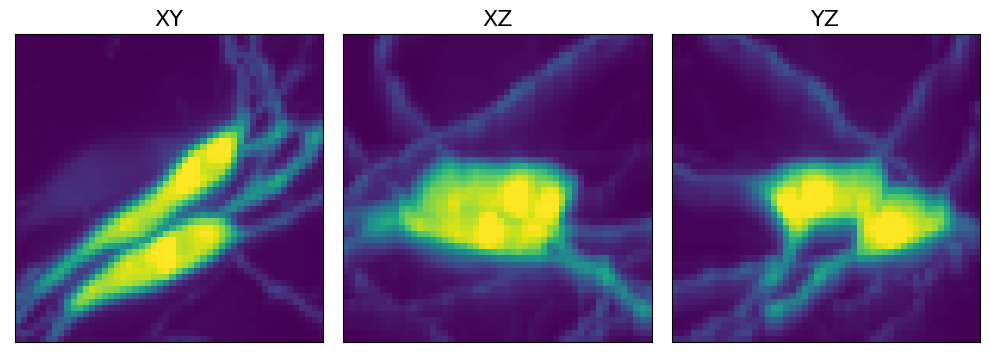


Fitted Gaussian


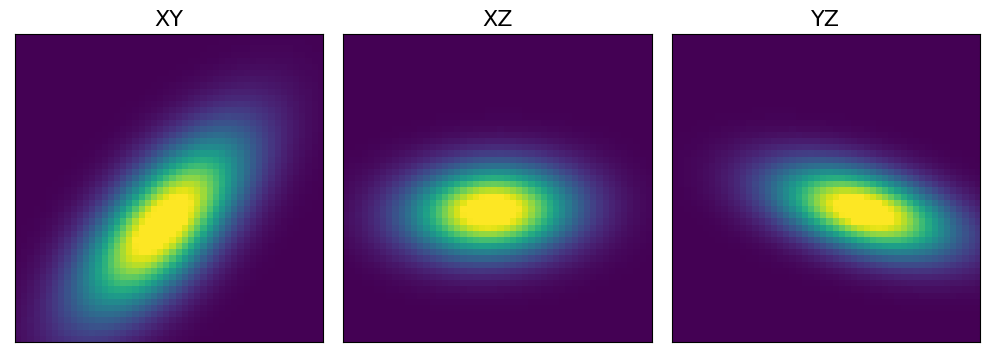

N012-685222
{'soma': array([14468.958175, 11321.118494, 15883.614385]), 'soma_offset': array([15.81485714,  5.12914286, -4.        ]), 'radii': array([28.63582961, 34.12100336, 83.57501106]), 'volume': 342055.52924040286, 'rsquared': 0.5055558970579743, 'primary_axis': array([0.49921898, 0.85229713, 0.15610896])}

Soma Patch


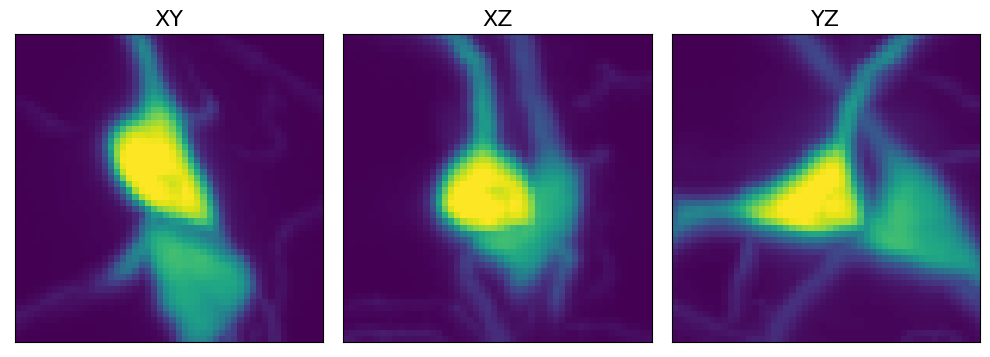


Fitted Gaussian


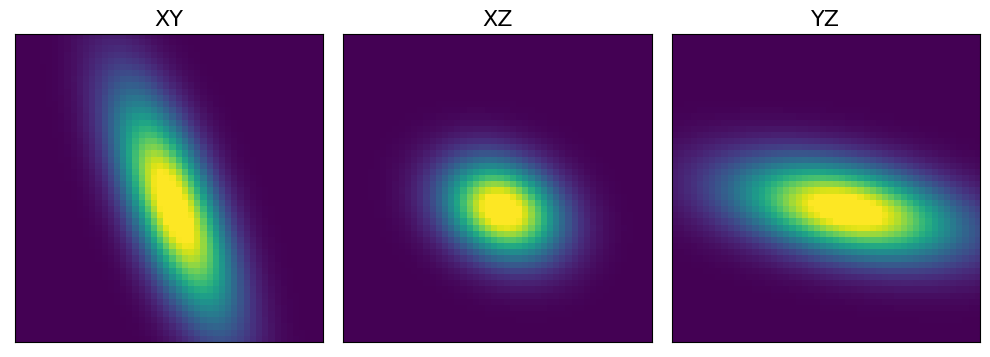

N013-685222
{'soma': array([14497.874997, 11370.467073, 15898.635801]), 'soma_offset': array([ 0.        ,  0.99733333, 14.66666667]), 'radii': array([28.15144015, 34.26847589, 97.2307502 ]), 'volume': 392905.087526849, 'rsquared': 0.5510076703304856, 'primary_axis': array([0.49330306, 0.85168755, 0.17686267])}

Soma Patch


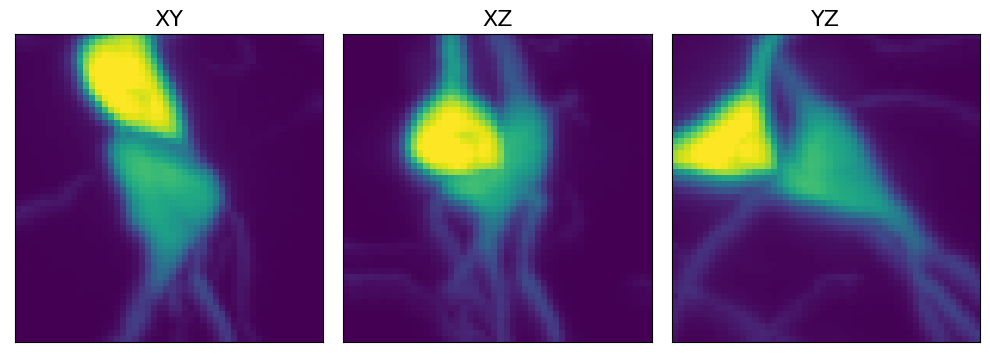


Fitted Gaussian


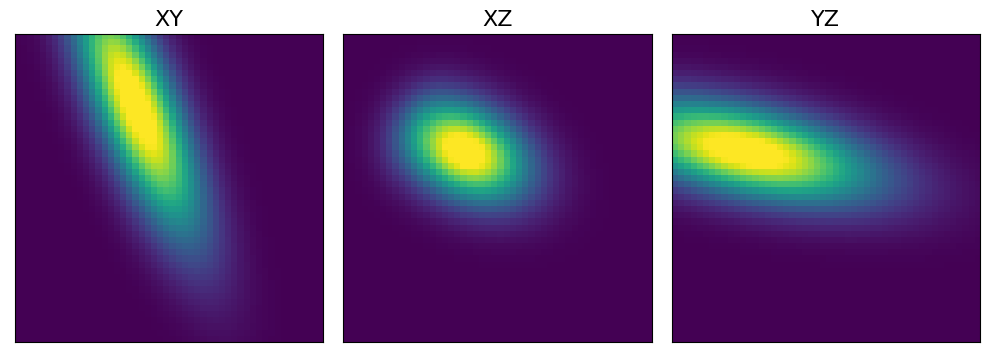

In [ ]:
# old_df = pd.read_excel("/data/LC_cells.xlsx")
# double_cells = old_df.loc[lambda df: df["Instance"]==2, "ID-Sample"].values

for id in double_cells:
    # if id not in df["id"].values:
    #     continue
    print(id)
    brain_id = id.split("-")[-1]
    soma_xyz = somas_df.loc[id, ["x", "y", "z"]].values.astype("float")

    result, blob, fitted_blob = run_shape_estimation(imgs[brain_id], soma_xyz)

    print(result)

    # Visualize results
    print("\nSoma Patch")
    img_util.plot_mips(blob)

    print("\nFitted Gaussian")
    img_util.plot_mips(fitted_blob)